<a href="https://colab.research.google.com/github/corrielynnyuill-debug/Assignment12-CLY/blob/main/Assignment12_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X_train shape: (60000, 28, 28)
y_train shape: (60000,)


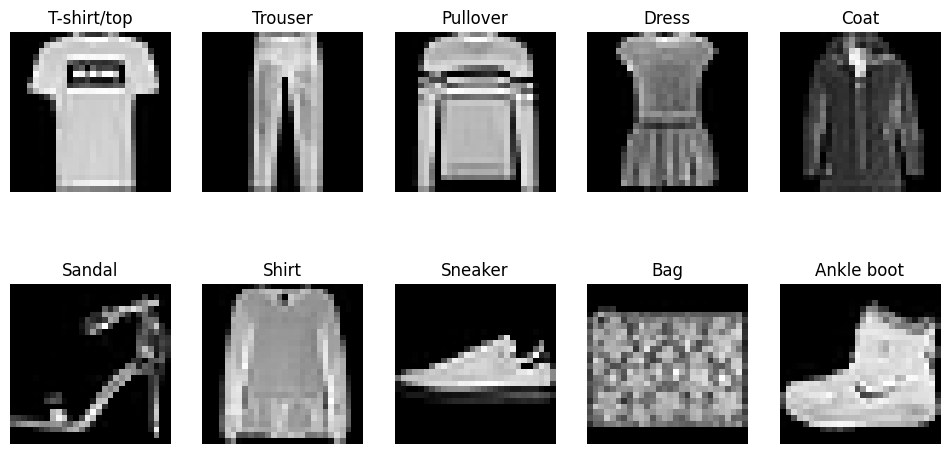

<Figure size 640x480 with 0 Axes>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names for visualization
class_names =[
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

# Visualize sample images from each class
plt.figure(figsize=(12, 6))
for i in range(10):
  idx = np.where(y_train == i)[0][0] # first occurence of each class
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[idx], cmap='gray')
  plt.title(class_names[i])
  plt.axis('off')
plt.show()

plt.suptitle('Sample images from each class of Fashion MNIST')
plt.tight_layout()
plt.show()


Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6851 - loss: 0.8525 - val_accuracy: 0.7820 - val_loss: 0.5950
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7974 - loss: 0.5590 - val_accuracy: 0.8101 - val_loss: 0.5233
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8212 - loss: 0.5015 - val_accuracy: 0.8253 - val_loss: 0.4884
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8356 - loss: 0.4608 - val_accuracy: 0.8377 - val_loss: 0.4499
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8459 - loss: 0.4308 - val_accuracy: 0.8387 - val_loss: 0.4423
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8526 - loss: 0.4106 - val_accuracy: 0.8491 - val_loss: 0.4217
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8581 - loss: 0.3951 - val_accuracy: 0.8565 - val_loss: 0.3984
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8626 - loss: 0

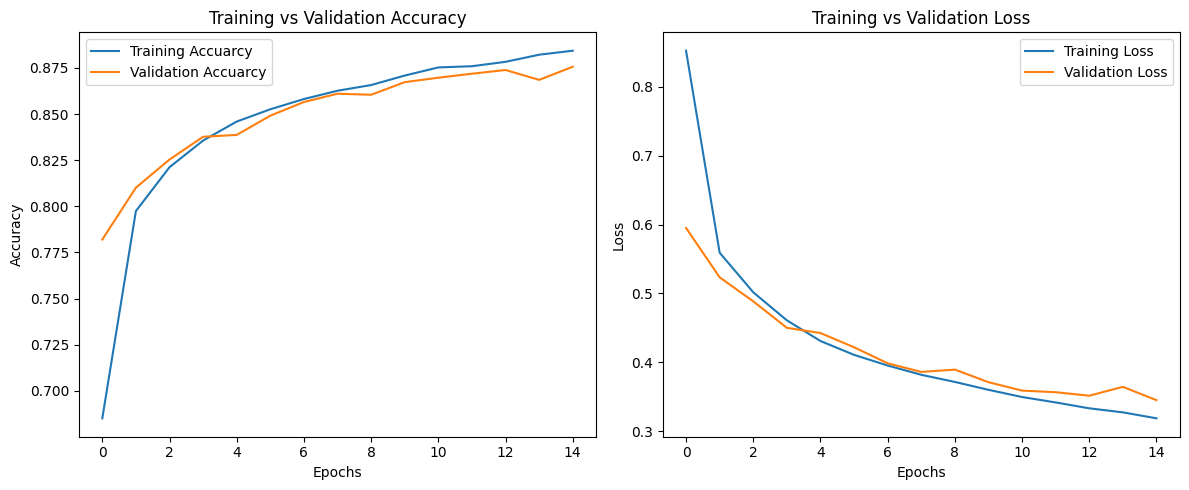

In [8]:
# Image Preprocessing
from re import VERBOSE
from IPython.core import history
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

# Normalize Pixel values
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

# Data Augementation Generator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Fit generator on training images
datagen.fit(X_train.reshape(-1,28,28,1))

# Flatten images for a feedforward neural network
X_train_flat = X_train.reshape(len(X_train),28*28)
X_test_flat = X_test.reshape(len(X_test),28*28)

print('Flattened training shape:', X_train_flat.shape)
print('Flattened testing shape:', X_test_flat.shape)

# One-hot encode labels for categorical crossentropy
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Build a simple feedforward neural network
model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),  # Hidden layer with ReLU
    Dense(128, activation='relu'),                      # Optional second hidden layer
    Dense(10, activation='softmax')                     # Output layer for 10 classes
])

model.summary()

# Compile the model using Adam optimizer and categorical crossentropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = model.fit(
    X_train_flat,
    y_train_cat,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

# Training curve (Loss & Accuracy) Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuarcy')
plt.plot(history.history['val_accuracy'], label='Validation Accuarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.tight_layout()
plt.show()

# Predict class probabilities
y_pred_prob = model.predict(X_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test

# Classification Report
print('Classification Report:\n',  classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test Accuracy Overall
test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc*100:.2f}%')

